In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fetch_california_housing.xlsx.zip to fetch_california_housing.xlsx.zip


In [ ]:
import zipfile

with zipfile.ZipFile("fetch_california_housing.xlsx.zip", "r") as zip_ref:
    zip_ref.extractall("data")

In [ ]:
import os
print(os.listdir("data"))

['fetch_california_housing.xlsx']


In [ ]:
import pandas as pd

df = pd.read_excel("data/fetch_california_housing.xlsx")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  int64  
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  int64  
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 1.4 MB


In [ ]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
target,0


In [ ]:
x=df[['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']]
x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25


In [ ]:
y=df['target']
y.head()

,target
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [ ]:
import tensorflow as tf
from tensorflow import keras
model = keras.Sequential([keras.layers.Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [ ]:
history = model.fit(x_train, y_train,validation_split=0.2,epochs=50,batch_size=32,verbose=1)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.8166 - mae: 0.6273 - val_loss: 0.4734 - val_mae: 0.4766
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4094 - mae: 0.4557 - val_loss: 0.4246 - val_mae: 0.4497
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3759 - mae: 0.4338 - val_loss: 0.3972 - val_mae: 0.4342
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3578 - mae: 0.4235 - val_loss: 0.3909 - val_mae: 0.4375
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3440 - mae: 0.4156 - val_loss: 0.3681 - val_mae: 0.4265
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3383 - mae: 0.4093 - val_loss: 0.3589 - val_mae: 0.4239
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3368 - mae: 0.4046 - val_loss: 0.3537 - val_mae: 0.4152
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3206 - mae: 0.3982 - val_loss: 0.3422 - val_mae: 0.4093
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

In [ ]:
# 7. Evaluate the Model
test_loss, test_mae = model.evaluate(x_test,y_test,verbose=1)

# MSE is the loss because loss='mse'
test_mse = test_loss
print(f"Test MAE: {test_mae:.4f}")
print(f"Test MSE: {test_mse:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2840 - mae: 0.3569
Test MAE: 0.3569
Test MSE: 0.2840


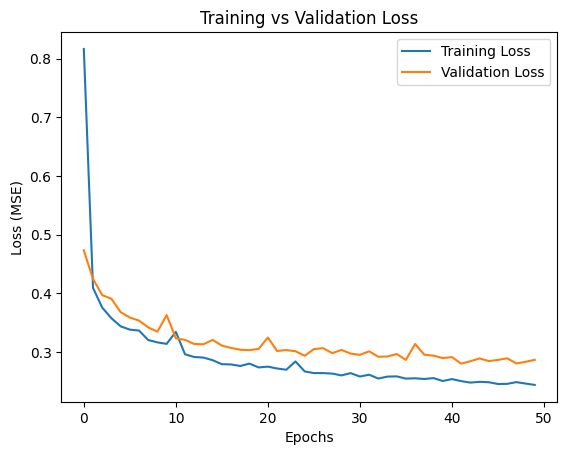

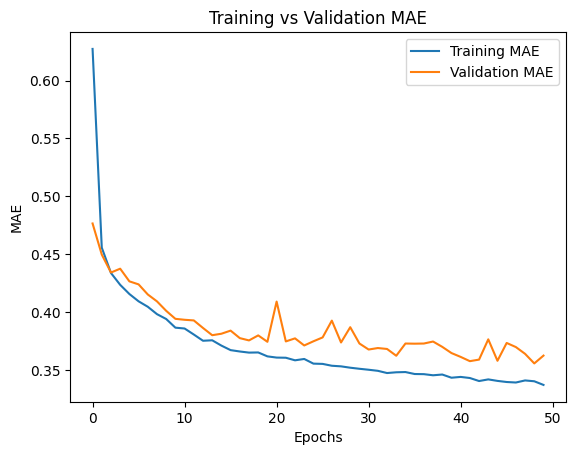

In [ ]:
import matplotlib.pyplot as plt

# Loss Graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# MAE Graph
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.show()